# Парсинг вакансий по мл c [hh.ru](https://spb.hh.ru/) и их анализ

In [1]:
import requests
import time
import pandas as pd
from google.colab import userdata
API_KEY = userdata.get('API_KEY')
import functions
import matplotlib.pyplot as plt

In [2]:
rates = requests.get(f'https://v6.exchangerate-api.com/v6/{API_KEY}/latest/RUB').json()['conversion_rates']

In [3]:
jobs = []
for i in range(20):
  items = requests.get('https://api.hh.ru/vacancies', params={'page': i, 'per_page': 100, 'text': 'ml'}).json()['items']
  jobs.extend(items)
  if len(items) < 100:
    break
jobs = [job for job in jobs if functions.in_(['data',
                                    'python',
                                    'ml',
                                    'engineer',
                                    'machine learning',
                                    'ai'
                                    'nlp',
                                    'cv',
                                    'computer vision',
                                    'дата',
                                    'данных',
                                    'компьютерное зрение',
                                    'LLM', 'recsys'], job['name'])]
if len(jobs) < 1000:
    additional_jobs = requests.get('https://api.hh.ru/vacancies', params={'page': 0, 'per_page': 20, 'text': 'data'}).json()['items']
    jobs.extend(additional_jobs[:1001 - len(jobs)])  # Добавляем недостающие

In [4]:
print('Количество вакансий:', len(jobs))

Количество вакансий: 1003


In [5]:
min_salaries = []
max_salaries = []
salaries = []

for i, job in enumerate(jobs):
    resp = requests.get(f'https://api.hh.ru/vacancies/{job["id"]}').json()
    time.sleep(1)

    job['key_skills'] = resp.get('key_skills', [])

    salary = job['salary']

    if salary is not None:
        min_salary = salary['from']
        max_salary = salary['to']

        if min_salary is None:
            salary_amount = (max_salary * 0.66 + max_salary) / 2
        elif max_salary is None:
            salary_amount = (min_salary + min_salary * 1.5) / 2
        else:
            salary_amount = (min_salary + max_salary) / 2

        if salary['currency'] in rates:
            salary_amount /= rates[salary['currency']]
            if min_salary is not None:
                min_salary = min_salary / rates[salary['currency']]
            if max_salary is not None:
                max_salary = max_salary / rates[salary['currency']]

        job['salary'] = salary_amount
        salaries.append(int(salary_amount))
        min_salaries.append(min_salary)
        max_salaries.append(max_salary)
    else:
        salaries.append(None)
        min_salaries.append(None)
        max_salaries.append(None)

salaries = pd.Series(salaries)
min_salaries = pd.Series(min_salaries)
max_salaries = pd.Series(max_salaries)

Text(0, 0.5, 'Частота')

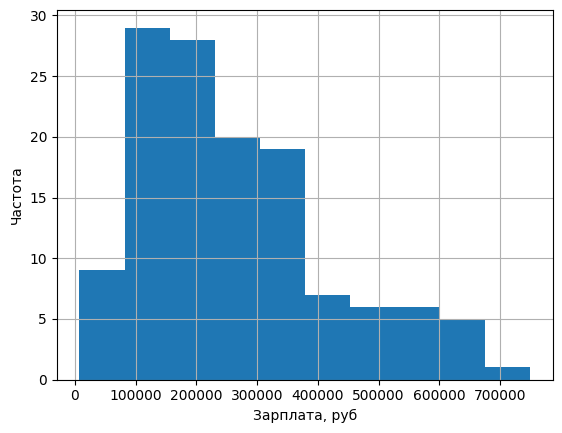

In [6]:
salaries.hist()
plt.xlabel('Зарплата, руб')
plt.ylabel('Частота')

In [7]:
salaries.describe()

,0
count,130.000000
mean,264766.369231
std,160512.816762
min,7500.000000
25%,142350.000000
50%,225000.000000
75%,336475.000000
max,750000.000000


In [8]:
jobs_df = pd.DataFrame(jobs)
jobs_df.head(3)

,id,premium,name,department,has_test,response_letter_required,area,salary,type,address,...,accept_temporary,professional_roles,accept_incomplete_resumes,experience,employment,adv_response_url,is_adv_vacancy,adv_context,key_skills,branding
0,107640290,False,Python developer,None,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",NaN,"{'id': 'open', 'name': 'Открытая'}",None,...,False,"[{'id': '96', 'name': 'Программист, разработчи...",False,"{'id': 'between1And3', 'name': 'От 1 года до 3...","{'id': 'full', 'name': 'Полная занятость'}",None,False,None,[],NaN
1,107534721,False,Python-разработчик (Junior-Middle) по работе с...,None,False,False,"{'id': '1', 'name': 'Москва', 'url': 'https://...",100000.0,"{'id': 'open', 'name': 'Открытая'}",None,...,False,"[{'id': '96', 'name': 'Программист, разработчи...",False,"{'id': 'between1And3', 'name': 'От 1 года до 3...","{'id': 'full', 'name': 'Полная занятость'}",None,False,None,"[{'name': 'Python'}, {'name': 'Git'}, {'name':...",NaN
2,107744449,False,Python-разработчик,None,False,False,"{'id': '56', 'name': 'Курск', 'url': 'https://...",187500.0,"{'id': 'open', 'name': 'Открытая'}",None,...,False,"[{'id': '96', 'name': 'Программист, разработчи...",False,"{'id': 'between1And3', 'name': 'От 1 года до 3...","{'id': 'full', 'name': 'Полная занятость'}",None,False,None,"[{'name': 'Python'}, {'name': 'ML'}, {'name': ...",NaN


In [9]:
jobs_df.key_skills = jobs_df.key_skills.apply(lambda skills: [skill['name'] for skill in skills])

In [10]:
jobs_df.head(3).key_skills

,key_skills
0,[]
1,"[Python, Git, SQL, PostgreSQL, Docker, Docker-..."
2,"[Python, ML, Векторные базы данных, AI]"


In [11]:
jobs_df.employer = jobs_df.employer.apply(lambda el: el['name'])
jobs_df.schedule = jobs_df.schedule.apply(lambda el: el['name'])
jobs_df.area = jobs_df.area.apply(lambda el: el['name'])
jobs_df.professional_roles = jobs_df.professional_roles.apply(lambda el: el[0]['name'])
jobs_df.working_time_intervals = jobs_df.working_time_intervals.apply(lambda el: el[0]['name'] if len(el) > 0 else None)
jobs_df.employment = jobs_df.employment.apply(lambda el: el['name'])
jobs_df.department = jobs_df.department.apply(lambda el: el['name'] if el is not None else None)
jobs_df.experience = jobs_df.experience.apply(lambda el: el['name'])

jobs_df['average_salary'] = salaries
jobs_df['min_salary'] = min_salaries
jobs_df['max_salary'] = max_salaries

jobs_df.drop(['type',
              'salary',
              'adv_response_url',
              'is_adv_vacancy',
              'adv_context',
              'show_logo_in_search',
              'branding',
              'accept_incomplete_resumes',
              'working_days',
              'working_time_modes',
              'response_url',
              'sort_point_distance',
              'contacts',
              'relations',
              'alternate_url',
              'url',
              'insider_interview',
              'apply_alternate_url',
              'archived'], axis=1, inplace=True)
jobs_df.set_index('id', inplace=True)

In [12]:
jobs_df.head(3)

,premium,name,department,has_test,response_letter_required,area,address,published_at,created_at,employer,...,schedule,working_time_intervals,accept_temporary,professional_roles,experience,employment,key_skills,average_salary,min_salary,max_salary
id,,,,,,,,,,,,,,,,,,,,,
107640290,False,Python developer,None,False,False,Москва,None,2024-09-23T13:46:42+0300,2024-09-23T13:46:42+0300,Сбер Лигал,...,Полный день,None,False,"Программист, разработчик",От 1 года до 3 лет,Полная занятость,[],NaN,NaN,NaN
107534721,False,Python-разработчик (Junior-Middle) по работе с...,None,False,False,Москва,None,2024-09-19T21:28:15+0300,2024-09-19T21:28:15+0300,good.sale,...,Полный день,None,False,"Программист, разработчик",От 1 года до 3 лет,Полная занятость,"[Python, Git, SQL, PostgreSQL, Docker, Docker-...",100000.0,50000.0,150000.0
107744449,False,Python-разработчик,None,False,False,Курск,None,2024-09-25T10:32:23+0300,2024-09-25T10:32:23+0300,EFSOL,...,Удаленная работа,None,False,"Программист, разработчик",От 1 года до 3 лет,Полная занятость,"[Python, ML, Векторные базы данных, AI]",187500.0,150000.0,NaN


In [13]:
jobs_df.shape

(1003, 21)

In [14]:
functions.flatten_series(jobs_df.key_skills.tolist()).value_counts().head(20)

,count
Python,510
SQL,227
ML,112
Docker,93
PyTorch,92
PostgreSQL,87
Linux,75
Machine Learning,75
Kubernetes,60
Git,60


In [15]:
jobs_df['published_at'] = pd.to_datetime(jobs_df['published_at'], utc=True)
now = pd.Timestamp.now(tz='UTC')

# Вычисляем разницу между текущей датой и временем публикации в часах
jobs_df['hours_since_publication'] = ((now - jobs_df['published_at']).dt.total_seconds() // 3600).astype(int)
jobs_df.drop(['published_at', 'created_at'], axis=1, inplace=True)
jobs_df.head(3)


,premium,name,department,has_test,response_letter_required,area,address,employer,snippet,schedule,working_time_intervals,accept_temporary,professional_roles,experience,employment,key_skills,average_salary,min_salary,max_salary,hours_since_publication
id,,,,,,,,,,,,,,,,,,,,
107640290,False,Python developer,None,False,False,Москва,None,Сбер Лигал,"{'requirement': 'Docker, docker-compose. Опыт ...",Полный день,None,False,"Программист, разработчик",От 1 года до 3 лет,Полная занятость,[],NaN,NaN,NaN,51
107534721,False,Python-разработчик (Junior-Middle) по работе с...,None,False,False,Москва,None,good.sale,{'requirement': 'Linux (bash). Опыт работы с м...,Полный день,None,False,"Программист, разработчик",От 1 года до 3 лет,Полная занятость,"[Python, Git, SQL, PostgreSQL, Docker, Docker-...",100000.0,50000.0,150000.0,139
107744449,False,Python-разработчик,None,False,False,Курск,None,EFSOL,{'requirement': 'Базовым пониманием <highlight...,Удаленная работа,None,False,"Программист, разработчик",От 1 года до 3 лет,Полная занятость,"[Python, ML, Векторные базы данных, AI]",187500.0,150000.0,NaN,6


Таргет может быть разным, но скорее всего будующая модель будет предсказывать зарплату

average_salary и hours_since_publication - целочисленные,  
min_salary и max_salary - дробные